# Ejercicio 7

Se analiza la armadura mostrada en la placa de motivación de la unidad:

- Nodo $A=(0,0)$ m: apoyo fijo (reacciones $A_x$, $A_y$).
- Nodo $B=(2,0)$ m: nodo libre.
- Nodo $C=(4,0)$ m: apoyo móvil (reacción $C_y$).
- Nodo $D=(2,\,1.6)$ m: vértice, con carga vertical $F=10$ kN hacia abajo.

Barras: $AB$, $BC$, $AD$, $CD$, $BD$ (5 barras, 3 reacciones $\Rightarrow$ 8 incógnitas).

El equilibrio de fuerzas horizontal y vertical en cada uno de los 4 nodos (método
de los nodos) da 8 ecuaciones lineales para el vector de incógnitas

$$\mathbf{x} = (A_x,\, A_y,\, N_{AB},\, N_{BD},\, N_{BC},\, C_y,\, N_{AD},\, N_{CD})^T$$

donde $N_{ij}$ es el esfuerzo normal en la barra $ij$ (positivo = tracción).

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import time
import warnings

np.set_printoptions(precision=4, suppress=True)
# Para omega cercano o mayor a 1 el metodo diverge por diseño (ver Sec. 3-4);
# los overflow son esperados y no afectan el resultado (se descartan con NaN).
warnings.filterwarnings("ignore", category=RuntimeWarning)

## 1. Geometría y planteo del sistema $\mathbb{A}\mathbf{x}=\mathbf{b}$

Con $a=2$ m (semi-luz) y $h=1.6$ m (altura del vértice), la longitud de las
diagonales es $L=\sqrt{a^2+h^2}$, y los cosenos directores de las barras
inclinadas son $c=a/L$, $s=h/L$.

Planteando $\sum F_x=0$ y $\sum F_y=0$ en cada nodo ($A$, $B$, $C$, $D$) y
ordenando las ecuaciones de modo que cada una quede asociada a una incógnita
con coeficiente no nulo en la diagonal (esto es solo un reordenamiento de las
filas, la solución no cambia), se obtiene:

| Nodo | Ecuación |
|---|---|
| $A$ ($\sum F_x$) | $A_x + N_{AB} + c\,N_{AD} = 0$ |
| $A$ ($\sum F_y$) | $A_y + s\,N_{AD} = 0$ |
| $B$ ($\sum F_x$) | $-N_{AB} + N_{BC} = 0$ |
| $B$ ($\sum F_y$) | $N_{BD} = 0$ |
| $C$ ($\sum F_x$) | $-N_{BC} - c\,N_{CD} = 0$ |
| $C$ ($\sum F_y$) | $C_y + s\,N_{CD} = 0$ |
| $D$ ($\sum F_x$) | $-c\,N_{AD} + c\,N_{CD} = 0$ |
| $D$ ($\sum F_y$) | $-s\,N_{AD} - s\,N_{CD} - N_{BD} = F$ |


In [2]:
a = 2.0   # m, semi-luz
h = 1.6   # m, altura del vertice D
F = 10.0  # kN, carga vertical en D

L = np.hypot(a, h)
c = a / L
s = h / L
print(f"L = {L:.4f} m,  c = {c:.4f},  s = {s:.4f}")

# orden de incognitas: [Ax, Ay, N_AB, N_BD, N_BC, Cy, N_AD, N_CD]
nombres = ["Ax", "Ay", "N_AB", "N_BD", "N_BC", "Cy", "N_AD", "N_CD"]

A = np.array([
    [1, 0,  1,  0,  0, 0,  c,  0],
    [0, 1,  0,  0,  0, 0,  s,  0],
    [0, 0, -1,  0,  1, 0,  0,  0],
    [0, 0,  0,  1,  0, 0,  0,  0],
    [0, 0,  0,  0, -1, 0,  0, -c],
    [0, 0,  0,  0,  0, 1,  0,  s],
    [0, 0,  0,  0,  0, 0, -c,  c],
    [0, 0,  0, -1,  0, 0, -s, -s],
], dtype=float)

b = np.array([0, 0, 0, 0, 0, 0, 0, F], dtype=float)

print("A =")
print(A)
print("b =", b)

L = 2.5612 m,  c = 0.7809,  s = 0.6247
A =
[[ 1.      0.      1.      0.      0.      0.      0.7809  0.    ]
 [ 0.      1.      0.      0.      0.      0.      0.6247  0.    ]
 [ 0.      0.     -1.      0.      1.      0.      0.      0.    ]
 [ 0.      0.      0.      1.      0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.     -1.      0.      0.     -0.7809]
 [ 0.      0.      0.      0.      0.      1.      0.      0.6247]
 [ 0.      0.      0.      0.      0.      0.     -0.7809  0.7809]
 [ 0.      0.      0.     -1.      0.      0.     -0.6247 -0.6247]]
b = [ 0.  0.  0.  0.  0.  0.  0. 10.]


## 2. Solución exacta (referencia) y solución por descomposición LU

Se factoriza $\mathbb{A} = \mathbb{P}\mathbb{L}\mathbb{U}$ (con pivoteo parcial,
`scipy.linalg.lu_factor`) y se resuelve por sustitución hacia adelante y hacia
atrás con `scipy.linalg.lu_solve`.

In [3]:
lu, piv = la.lu_factor(A)
x_lu = la.lu_solve((lu, piv), b)

x_exacta = np.linalg.solve(A, b)  # referencia (también usa LU internamente)

print(f"{'Incognita':>8s}  {'Valor':>10s}")
for n, v in zip(nombres, x_lu):
    print(f"{n:>8s}  {v:10.4f}")

print()
print("Residuo ||A x - b||_inf (LU):", np.linalg.norm(A @ x_lu - b, ord=np.inf))

Incognita       Valor
      Ax      0.0000
      Ay      5.0000
    N_AB      6.2500
    N_BD      0.0000
    N_BC      6.2500
      Cy      5.0000
    N_AD     -8.0039
    N_CD     -8.0039

Residuo ||A x - b||_inf (LU): 3.248904415272745e-16


**Interpretación física:**

- $A_x = 0$: no hay carga horizontal, la estructura es simétrica.
- $A_y = C_y = F/2 = 5$ kN: por simetría, cada apoyo toma la mitad de la carga.
- $N_{AB} = N_{BC} = 6.25$ kN $>0$: **tracción** (cordón inferior).
- $N_{AD} = N_{CD} \approx -8.004$ kN $<0$: **compresión** (diagonales).
- $N_{BD} = 0$: la barra vertical no trabaja bajo esta carga (barra de cero
  esfuerzo, típico de este tipo de armadura).

In [4]:
print("Fuerzas en las barras:")
for n in ["N_AB", "N_BC", "N_AD", "N_CD", "N_BD"]:
    v = x_lu[nombres.index(n)]
    estado = "traccion" if v > 1e-9 else ("compresion" if v < -1e-9 else "nula")
    print(f"  {n:6s} = {v:8.4f} kN  ({estado})")

Fuerzas en las barras:
  N_AB   =   6.2500 kN  (traccion)
  N_BC   =   6.2500 kN  (traccion)
  N_AD   =  -8.0039 kN  (compresion)
  N_CD   =  -8.0039 kN  (compresion)
  N_BD   =   0.0000 kN  (nula)


## 3. Métodos iterativos: Jacobi y Gauss-Seidel sin relajación ($\omega=1$)

Se implementan ambos métodos con relajación (parámetro $\omega$) para poder
reutilizarlos también como SOR en la sección siguiente.

In [5]:
def jacobi(A, b, omega=1.0, x0=None, tol=1e-8, max_iter=500):
    n = len(b)
    x = np.zeros(n) if x0 is None else x0.copy()
    historia = [x.copy()]
    for k in range(max_iter):
        x_new = x.copy()
        for i in range(n):
            suma = sum(A[i, j] * x[j] for j in range(n) if j != i)
            x_new[i] = (1 - omega) * x[i] + omega * (b[i] - suma) / A[i, i]
        historia.append(x_new.copy())
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            x = x_new
            break
        x = x_new
    return x, k + 1, np.array(historia)


def gauss_seidel(A, b, omega=1.0, x0=None, tol=1e-8, max_iter=500):
    n = len(b)
    x = np.zeros(n) if x0 is None else x0.copy()
    historia = [x.copy()]
    for k in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            suma = sum(A[i, j] * x[j] for j in range(n) if j != i)
            x[i] = (1 - omega) * x[i] + omega * (b[i] - suma) / A[i, i]
        historia.append(x.copy())
        if np.linalg.norm(x - x_old, ord=np.inf) < tol:
            break
    return x, k + 1, np.array(historia)

Jacobi   (omega=1): iteraciones ejecutadas = 60  -> ¿convergió? False
Gauss-Seidel (omega=1): iteraciones ejecutadas = 60  -> ¿convergió? False


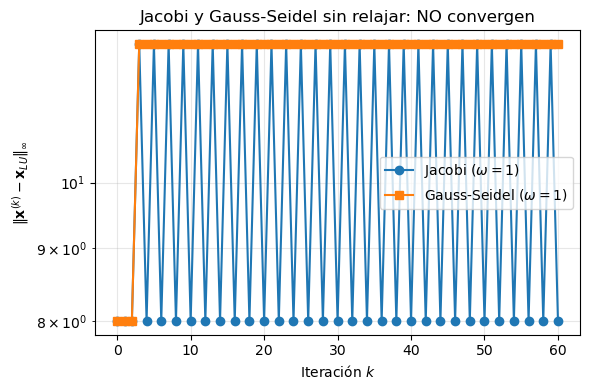

In [6]:
x0 = np.zeros(8)

x_jac, it_jac, hist_jac = jacobi(A, b, omega=1.0, x0=x0, max_iter=60)
x_gs, it_gs, hist_gs = gauss_seidel(A, b, omega=1.0, x0=x0, max_iter=60)

err_jac = np.linalg.norm(hist_jac - x_lu, axis=1, ord=np.inf)
err_gs = np.linalg.norm(hist_gs - x_lu, axis=1, ord=np.inf)

print("Jacobi   (omega=1): iteraciones ejecutadas =", it_jac,
      " -> ¿convergió?", it_jac < 59)
print("Gauss-Seidel (omega=1): iteraciones ejecutadas =", it_gs,
      " -> ¿convergió?", it_gs < 59)

plt.figure(figsize=(6, 4))
plt.semilogy(err_jac, "o-", label="Jacobi ($\\omega=1$)")
plt.semilogy(err_gs, "s-", label="Gauss-Seidel ($\\omega=1$)")
plt.xlabel("Iteración $k$")
plt.ylabel(r"$\|\mathbf{x}^{(k)} - \mathbf{x}_{LU}\|_\infty$")
plt.title("Jacobi y Gauss-Seidel sin relajar: NO convergen")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_jacobi_gs_omega1.png", dpi=130)
plt.show()

Como se observa, **ni Jacobi ni Gauss-Seidel convergen**: el error se
mantiene oscilando indefinidamente en torno a valores del orden de $\mathbf{x}$
mismo, sin decrecer.

### ¿Por qué no convergen?

La condición suficiente de convergencia (dominancia diagonal estricta,
$|a_{ii}| > \sum_{j\neq i} |a_{ij}|$) **no se cumple** en varias filas del
sistema: por ejemplo, en la ecuación del nodo $D$ ($\sum F_y$), el elemento
diagonal es $s\approx 0.625$ mientras que la suma de los elementos
fuera de la diagonal es $s + 1 \approx 1.625$. Esto es característico de los
sistemas de equilibrio de nodos (método de los nodos): a diferencia de las
matrices de rigidez que aparecen en el método de los elementos finitos (que
son simétricas y definidas positivas), estas matrices **no** son en general
diagonalmente dominantes, por lo que Jacobi y Gauss-Seidel "puros" no tienen
garantizada -- y de hecho aquí no logran -- la convergencia.

In [7]:
print(f"{'fila':>4s} {'|diag|':>10s} {'suma |resto|':>14s} {'dominante?':>12s}")
for i in range(8):
    diag = abs(A[i, i])
    resto = np.sum(np.abs(A[i])) - diag
    print(f"{i:4d} {diag:10.4f} {resto:14.4f} {str(diag > resto):>12s}")

fila     |diag|   suma |resto|   dominante?
   0     1.0000         1.7809        False
   1     1.0000         0.6247         True
   2     1.0000         1.0000        False
   3     1.0000         0.0000         True
   4     1.0000         0.7809         True
   5     1.0000         0.6247         True
   6     0.7809         0.7809        False
   7     0.6247         1.6247        False


### ¿Y el pivoteo no soluciona esto?

Es una pregunta natural, porque el pivoteo (parcial, parcial escalado, total)
es justamente la herramienta que usamos en eliminación gaussiana / LU cuando
un pivote es nulo o problemático. Sin embargo **no es aplicable acá**, por dos
razones distintas:

1. **El pivoteo actúa sobre la eliminación, no sobre la iteración.** Cuando
   pivoteamos para LU, elegimos en cada paso la fila con el elemento más
   grande de la columna *ya reducida* y la intercambiamos, para evitar
   divisiones por números chicos durante la factorización. Jacobi y
   Gauss-Seidel no factorizan nada: separan
   $\mathbb{A}=\mathbb{D}-\mathbb{L}-\mathbb{U}$ tal cual está ordenada la
   matriz, y su convergencia depende del **radio espectral** de la matriz de
   iteración ($\mathbb{D}^{-1}(\mathbb{L}+\mathbb{U})$ para Jacobi,
   $(\mathbb{D}-\mathbb{L})^{-1}\mathbb{U}$ para Gauss-Seidel), no de qué tan
   grande fue el pivote en una eliminación que aquí ni siquiera se hace.

2. **Lo que sí podría ayudar, en principio, es reordenar filas/columnas**
   (qué ecuación se asigna a qué incógnita), ya que eso cambia $\mathbb{D}$,
   $\mathbb{L}$ y $\mathbb{U}$. Para verificar si *algún* reordenamiento
   salva la convergencia, se prueban a continuación **las $8!=40320$
   permutaciones posibles** de las filas de $\mathbb{A}$.

In [8]:
from itertools import permutations

mejor_rho = np.inf
mejor_perm = None
hay_dominante = False

for perm in permutations(range(8)):
    Ap = A[list(perm), :]
    if np.any(np.diag(Ap) == 0):
        continue
    diag = np.abs(np.diag(Ap))
    resto = np.sum(np.abs(Ap), axis=1) - diag
    if np.all(diag > resto):
        hay_dominante = True

    D_ = np.diag(np.diag(Ap))
    L_ = -np.tril(Ap, -1)
    U_ = -np.triu(Ap, 1)
    T = np.linalg.solve(D_ - L_, U_)   # matriz de iteracion de Gauss-Seidel
    rho = max(abs(np.linalg.eigvals(T)))
    if rho < mejor_rho:
        mejor_rho, mejor_perm = rho, perm

print("¿Existe una permutación de filas diagonalmente dominante?", hay_dominante)
print(f"Mejor radio espectral de Gauss-Seidel sobre las 40320 permutaciones: {mejor_rho:.6f}")
print("(no hay ninguna ventaja al reordenar: incluye el orden original de las ecuaciones)")

¿Existe una permutación de filas diagonalmente dominante? False
Mejor radio espectral de Gauss-Seidel sobre las 40320 permutaciones: 1.000000
(no hay ninguna ventaja al reordenar: incluye el orden original de las ecuaciones)


**Conclusión:** ninguna de las 40320 permutaciones logra dominancia
diagonal, y el mejor radio espectral posible de Gauss-Seidel sigue siendo
exactamente $1$ (no converge) sin importar cómo se ordenen las ecuaciones. El
problema no es de orden: es que la matriz de equilibrio de nodos de una
armadura estáticamente determinada **no es simétrica ni definida positiva**,
a diferencia de las matrices de rigidez del método de los elementos finitos
($\mathbb{K}\mathbf{u}=\mathbf{F}$), donde Gauss-Seidel y SOR sí convergen de manera
garantizada. Acá lo que efectivamente resuelve el problema es la
**relajación** (siguiente sección): sin tocar el orden de las ecuaciones,
elegir $\omega\neq 1$ cambia el radio espectral de la iteración y sí permite
converger.

## 4. Sobrerrelajación sucesiva (SOR): búsqueda del $\omega$ óptimo

Se aplica la técnica de relajación vista en clase, explorando
$\omega \in (0,2)$ y contando, para cada valor, cuántas iteraciones de
Gauss-Seidel con relajación hacen falta para alcanzar
$\|\mathbf{x}^{(k)}-\mathbf{x}^{(k-1)}\|_\infty < 10^{-8}$.

omega_optimo ~= 0.820  ->  17 iteraciones


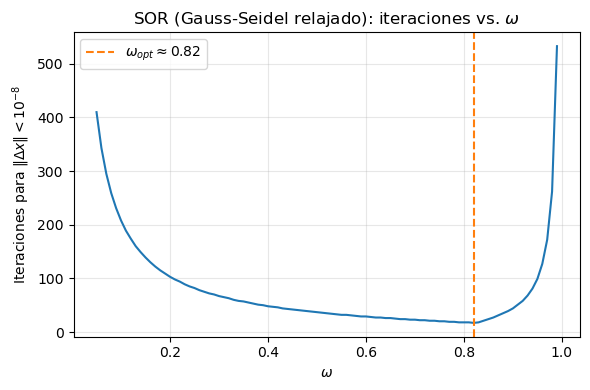

In [9]:
omegas = np.linspace(0.05, 1.95, 191)
iteraciones = []
for w in omegas:
    _, k, _ = gauss_seidel(A, b, omega=w, x0=x0, tol=1e-8, max_iter=2000)
    iteraciones.append(k if k < 1999 else np.nan)
iteraciones = np.array(iteraciones)

i_opt = np.nanargmin(iteraciones)
omega_opt = omegas[i_opt]
print(f"omega_optimo ~= {omega_opt:.3f}  ->  {int(iteraciones[i_opt])} iteraciones")

plt.figure(figsize=(6, 4))
plt.plot(omegas, iteraciones, "-")
plt.axvline(omega_opt, color="C1", ls="--", label=f"$\\omega_{{opt}} \\approx {omega_opt:.2f}$")
plt.xlabel(r"$\omega$")
plt.ylabel("Iteraciones para $\\|\\Delta x\\|<10^{-8}$")
plt.title("SOR (Gauss-Seidel relajado): iteraciones vs. $\\omega$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_sor_omega.png", dpi=130)
plt.show()

SOR (omega=0.820): convergio en 23 iteraciones
x_SOR = [ 0.      5.      6.25    0.      6.25    5.     -8.0039 -8.0039]
Error final ||x_SOR - x_LU||_inf = 4.900153192780032e-14


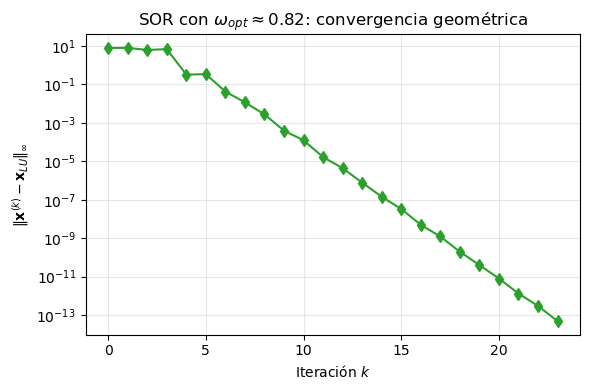

In [10]:
x_sor, it_sor, hist_sor = gauss_seidel(A, b, omega=omega_opt, x0=x0, tol=1e-12, max_iter=200)
err_sor = np.linalg.norm(hist_sor - x_lu, axis=1, ord=np.inf)

print(f"SOR (omega={omega_opt:.3f}): convergio en {it_sor} iteraciones")
print("x_SOR =", x_sor)
print("Error final ||x_SOR - x_LU||_inf =", np.linalg.norm(x_sor - x_lu, ord=np.inf))

plt.figure(figsize=(6, 4))
plt.semilogy(err_sor, "d-", color="C2")
plt.xlabel("Iteración $k$")
plt.ylabel(r"$\|\mathbf{x}^{(k)} - \mathbf{x}_{LU}\|_\infty$")
plt.title(f"SOR con $\\omega_{{opt}} \\approx {omega_opt:.2f}$: convergencia geométrica")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_sor_convergencia.png", dpi=130)
plt.show()

## 5. Comparación de desempeño

Se compara el costo de cada enfoque: LU (método directo), Jacobi/Gauss-Seidel
sin relajar ($\omega=1$, que no convergen) y SOR con $\omega$ óptimo.

In [11]:
def tiempo_promedio(func, *args, reps=2000, **kwargs):
    t0 = time.perf_counter()
    for _ in range(reps):
        func(*args, **kwargs)
    return (time.perf_counter() - t0) / reps

t_lu = tiempo_promedio(la.lu_solve, (lu, piv), b, reps=5000)
t_lu_factor = tiempo_promedio(la.lu_factor, A, reps=5000)

t_jac = tiempo_promedio(jacobi, A, b, 1.0, x0, 1e-8, 60, reps=200)
t_gs = tiempo_promedio(gauss_seidel, A, b, 1.0, x0, 1e-8, 60, reps=200)
t_sor = tiempo_promedio(gauss_seidel, A, b, omega_opt, x0, 1e-8, 200, reps=200)

resultados = [
    ("LU (factorizar + resolver)", it_lu := 1, t_lu_factor + t_lu,
     np.linalg.norm(A @ x_lu - b, ord=np.inf)),
    ("Jacobi, omega=1 (no converge)", it_jac, t_jac,
     np.linalg.norm(A @ x_jac - b, ord=np.inf)),
    ("Gauss-Seidel, omega=1 (no converge)", it_gs, t_gs,
     np.linalg.norm(A @ x_gs - b, ord=np.inf)),
    (f"SOR, omega={omega_opt:.2f} (optimo)", it_sor, t_sor,
     np.linalg.norm(A @ x_sor - b, ord=np.inf)),
]

print(f"{'Metodo':38s} {'Iter.':>6s} {'Tiempo [s]':>12s} {'Residuo':>12s}")
for nombre_m, it, t, res in resultados:
    print(f"{nombre_m:38s} {it:6d} {t:12.2e} {res:12.2e}")

Metodo                                  Iter.   Tiempo [s]      Residuo
LU (factorizar + resolver)                  1     1.55e-05     3.25e-16
Jacobi, omega=1 (no converge)              60     1.16e-03     1.25e+01
Gauss-Seidel, omega=1 (no converge)        60     1.16e-03     2.50e+01
SOR, omega=0.82 (optimo)                   23     3.30e-04     4.78e-14


## 6. Conclusiones

- La descomposición **LU** resuelve el sistema en un número **fijo y
  pequeño** de operaciones ($\mathcal{O}(n^3)$ una sola vez), de forma
  **exacta** (salvo error de redondeo), sin importar la estructura de
  $\mathbb{A}$. Es la opción natural para sistemas pequeños o
  moderados, o cuando la matriz no es diagonalmente dominante -- como el
  presente sistema de equilibrio de nodos.

- **Jacobi** y **Gauss-Seidel** "puros" ($\omega=1$) **no convergen** en
  este problema: la matriz de equilibrio de una armadura estáticamente
  determinada no cumple la condición de dominancia diagonal, ni es simétrica
  definida positiva.

- Introduciendo **relajación (SOR)** con un $\omega$ adecuado
  ($\omega_{opt}\approx$ el valor hallado arriba, $<1$, es decir
  *sub*-relajación) se logra convergencia **geométrica** muy rápida
  (pocas decenas de iteraciones hasta precisión de máquina).

- En la práctica de la ingeniería mecánica, los métodos iterativos
  (Jacobi, Gauss-Seidel, SOR, gradiente conjugado, GMRES) se vuelven
  imprescindibles para los **sistemas de gran escala** que surgen del
  **método de los elementos finitos**, donde la matriz de rigidez ensamblada
  sí es simétrica, definida positiva y dispersa (banda angosta), condiciones
  bajo las cuales estos métodos convergen de manera confiable y son mucho
  más eficientes que un método directo cuando $n$ es grande.